In [10]:
!pip install ultralytics roboflow -q

In [11]:
from roboflow import Roboflow
rf = Roboflow(api_key="yhDu5OiaBKJ5gUzikSLF")
project = rf.workspace("s-workspace-eyhgk").project("stairs-ramps-blqli")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [12]:
!yolo task=detect mode=train model=yolov8s.pt data="{dataset.location}/data.yaml" epochs=25 imgsz=800 plots=True

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Stairs-&-ramps-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [13]:
!yolo task=detect mode=val model=runs/detect/train-2/weights/best.pt data="{dataset.location}/data.yaml"

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3360.4±1866.2 MB/s, size: 248.2 KB)
val: Scanning /content/Stairs-&-ramps-2/valid/labels.cache... 78 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 14.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.3s
                   all         78        107      0.699      0.592      0.688      0.457
                  ramp         27         29      0.609      0.414      0.527      0.303
                stairs         70         78       0.79       0.77       0.85      0.612
Speed: 15.8ms preprocess, 15.9ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [14]:
from google.colab import files
files.download('runs/detect/train-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-2/weights/best.pt")

def analyze_image(image_path):
    results = model.predict(image_path, conf=0.4)
    detected = [model.names[int(box.cls)] for box in results[0].boxes]

    has_stairs = "stairs" in detected
    has_ramp = "ramp" in detected

    if has_stairs:
        grade = "B" if has_ramp else "C"
    else:
        grade = "A"

    annotated_path = "result.jpg"
    results[0].save(annotated_path)

    return grade, detected, annotated_path

In [16]:
import os
test_images = os.listdir(f"{dataset.location}/test/images")
print(test_images[:5])

['9507e863-000048030_jpg.rf.e7a8a9e98a298bf13c02b725fddb8d7d.jpg', 'ed04405b-000114529_jpg.rf.4a92c2f65782770d0e176f47f72c51e6.jpg', '7bc04ab3-000087020_jpg.rf.529085bbb2db5191865f5b66328a63f5.jpg', '76d02f76-000004622_jpg.rf.bf453cb029b81ec48bd3239aea3080f7.jpg', '48486853-000012561_jpg.rf.5fc9dc86d5982c52d63ea7fff099cd13.jpg']


In [17]:
grade, detected, img_path = analyze_image(f"{dataset.location}/test/images/{test_images[0]}")
print("등급:", grade)
print("탐지된 항목:", detected)


image 1/1 /content/Stairs-&-ramps-2/test/images/9507e863-000048030_jpg.rf.e7a8a9e98a298bf13c02b725fddb8d7d.jpg: 800x608 1 stairs, 52.0ms
Speed: 3.5ms preprocess, 52.0ms inference, 17.6ms postprocess per image at shape (1, 3, 800, 608)
등급: C
탐지된 항목: ['stairs']


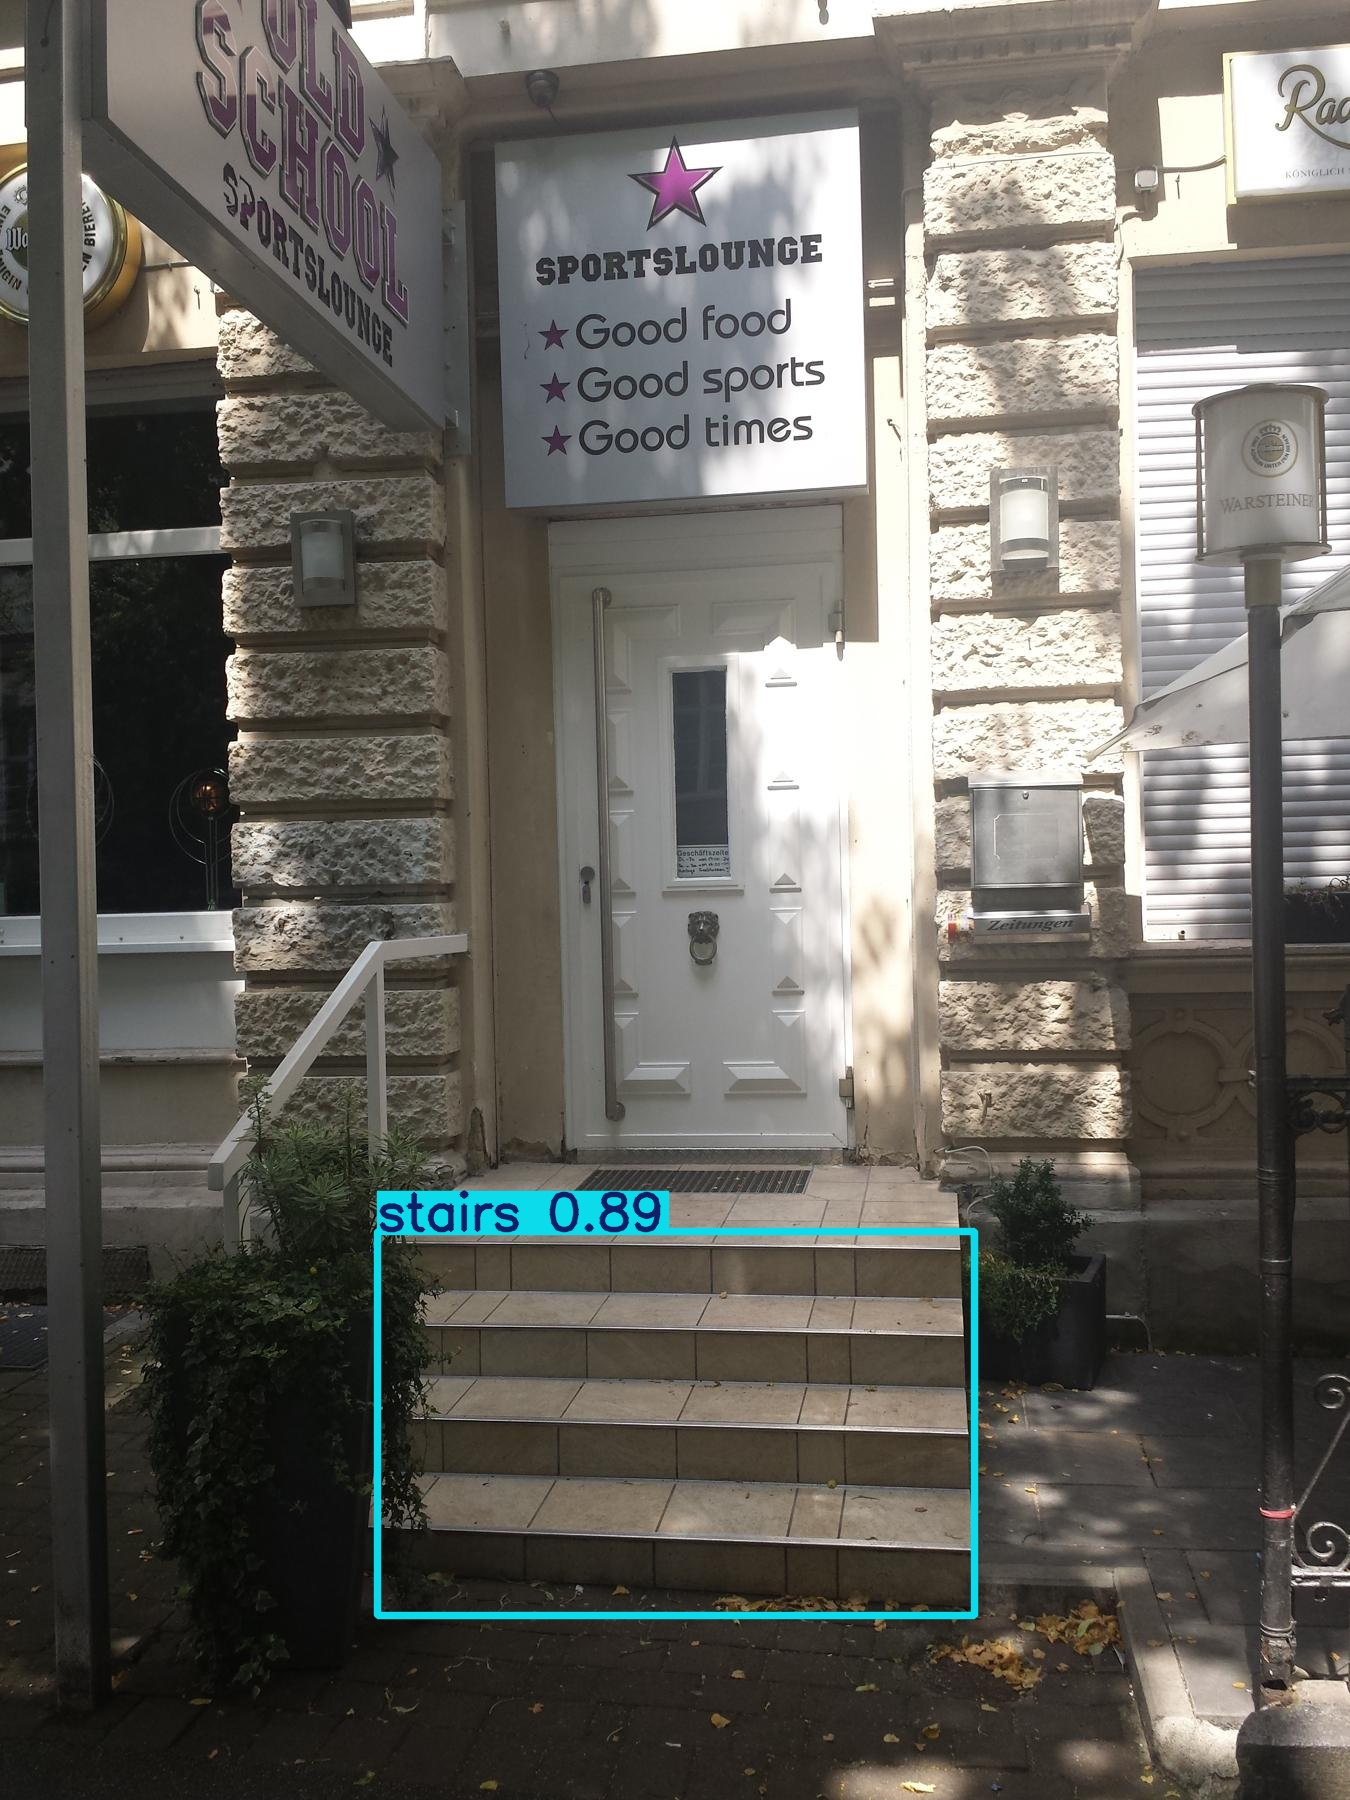

In [18]:
from IPython.display import Image, display
display(Image(img_path))